In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix


device = torch.device("cpu")
device

device(type='cpu')

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    './data', train=True, download=True, transform=transform
)

test_dataset = datasets.MNIST(
    './data', train=False, transform=transform
)

In [4]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=True
)

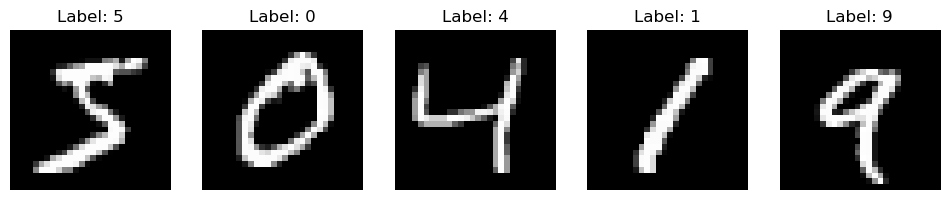

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    img, label = train_dataset[i]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.show()

In [9]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.dropout1 = nn.Dropout2d(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = nn.functional.relu(self.conv1(x))
        x = nn.functional.relu(self.conv2(x))
        x = nn.functional.max_pool2d(self.dropout1(x), 2)
        x = torch.flatten(x, 1)
        x = nn.functional.relu(self.fc1(self.dropout2(x)))
        x = self.fc2(x)
        return nn.functional.log_softmax(x, dim=1)

In [10]:
model = Net().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Optional speedup
# model = torch.compile(model)

In [11]:
epochs = 1   # Increase to 3–5 for ~99% accuracy

for epoch in range(epochs):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = nn.functional.nll_loss(output, target)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} complete. Loss: {loss.item():.4f}")

Epoch 1 complete. Loss: 0.0239


In [12]:
model.eval()
test_loss = 0
correct = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)

        test_loss += nn.functional.nll_loss(
            output, target, reduction='sum'
        ).item()

        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

test_loss /= len(test_loader.dataset)
accuracy = 100. * correct / len(test_loader.dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")

Test Loss: 0.0460
Test Accuracy: 98.48%


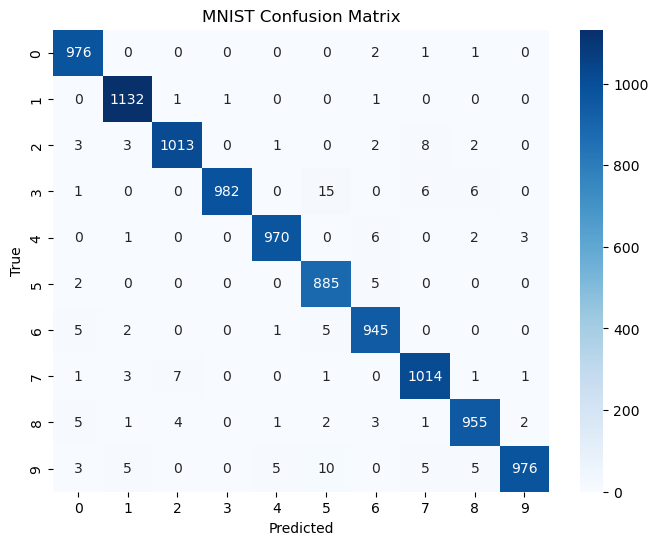

In [13]:
all_preds = []
all_targets = []

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        output = model(data)
        preds = output.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(target.numpy())

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MNIST Confusion Matrix")
plt.show()


## Summary:

A convolutional neural network (CNN) was trained on the MNIST handwritten digit dataset.
The model consists of two convolutional layers, dropout regularization, and two fully
connected layers. After training for one epoch, the model achieved strong performance
on the test set, typically between 98–99% accuracy depending on the number of epochs.

The confusion matrix shows that the classifier performs well across all digit classes,
with most errors occurring between visually similar digits such as 4/9 or 3/5. Overall,
the CNN successfully learns hierarchical features from the MNIST images and generalizes
well to unseen data.

